# 2D Wavelet Transform on Images
## Objective
Apply 2D Discrete Wavelet Transform (DWT) to decompose images into different frequency sub-bands and analyze their characteristics.

In [1]:
# Import required libraries
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from PIL import Image

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Image and Apply Preprocessing

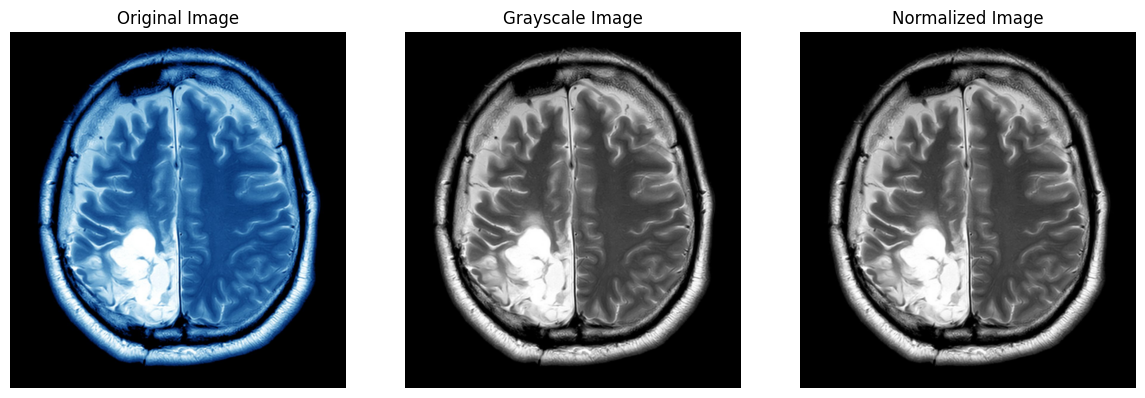

Image shape: (1200, 1130)
Image dtype: float32
Value range: [0.000, 1.000]


In [2]:
# Load the image
img = cv2.imread('brain.jpg')

# Convert to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Normalize the image (scale pixel values to 0-1)
normalized_img = gray_img.astype(np.float32) / 255.0

# Display original and preprocessed images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(normalized_img, cmap='gray')
plt.title('Normalized Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {normalized_img.shape}")
print(f"Image dtype: {normalized_img.dtype}")
print(f"Value range: [{normalized_img.min():.3f}, {normalized_img.max():.3f}]")

## 2. Apply 1-Level 2D Wavelet Transform
We'll use **Haar wavelet** for decomposition. Other options include:
- Daubechies wavelets (db2, db4, db8)
- Symlet wavelets (sym2, sym4, sym8)

In [3]:
# Apply 1-level 2D DWT using Haar wavelet
coeffs = pywt.dwt2(normalized_img, 'haar')

# Extract the four sub-bands
LL, (LH, HL, HH) = coeffs

print("Wavelet decomposition completed!")
print(f"LL (Approximation) shape: {LL.shape}")
print(f"LH (Horizontal detail) shape: {LH.shape}")
print(f"HL (Vertical detail) shape: {HL.shape}")
print(f"HH (Diagonal detail) shape: {HH.shape}")

Wavelet decomposition completed!
LL (Approximation) shape: (600, 565)
LH (Horizontal detail) shape: (600, 565)
HL (Vertical detail) shape: (600, 565)
HH (Diagonal detail) shape: (600, 565)


## 3-4. Display All Four Sub-band Images

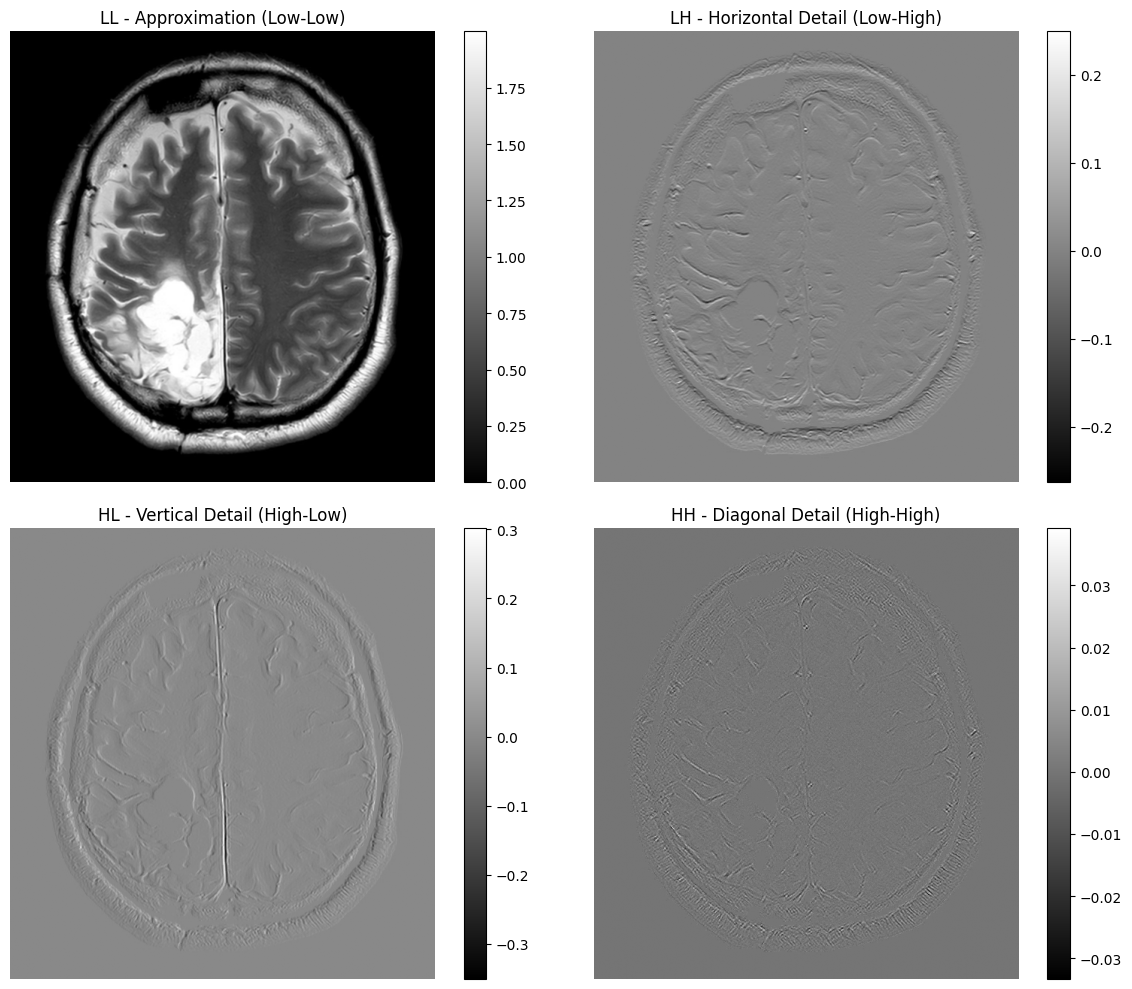

In [4]:
# Display all four sub-bands
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(LL, cmap='gray')
plt.title('LL - Approximation (Low-Low)')
plt.colorbar()
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(LH, cmap='gray')
plt.title('LH - Horizontal Detail (Low-High)')
plt.colorbar()
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(HL, cmap='gray')
plt.title('HL - Vertical Detail (High-Low)')
plt.colorbar()
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(HH, cmap='gray')
plt.title('HH - Diagonal Detail (High-High)')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

## 5. Characteristics of Each Sub-band

### **LL (Approximation) - Low-Low Frequencies**
- Contains the **main structure** and **average information** of the image
- Represents smooth regions and overall shape
- Has the **lowest frequency content**
- Looks like a downsampled version of the original image
- Contains most of the energy and visual information

### **LH (Horizontal Detail) - Low-High Frequencies**
- Captures **horizontal edges** and changes
- Highlights horizontal features like horizontal lines, boundaries
- Detects changes in the vertical direction
- Shows edges where there are transitions from top to bottom

### **HL (Vertical Detail) - High-Low Frequencies**
- Captures **vertical edges** and changes
- Highlights vertical features like vertical lines, boundaries
- Detects changes in the horizontal direction
- Shows edges where there are transitions from left to right

### **HH (Diagonal Detail) - High-High Frequencies**
- Captures **diagonal edges** and corner points
- Contains high-frequency noise and texture information
- Highlights diagonal features at 45° and 135°
- Shows rapid changes in both horizontal and vertical directions

## 6. Why Does LL Band Contain Most Important Information?

The **LL (Approximation) band** contains most of the important information because:

1. **Energy Concentration**: Natural images have most of their energy concentrated in low frequencies. The LL band captures these low-frequency components.

2. **Human Visual Perception**: Human eyes are more sensitive to low-frequency components (smooth regions, overall structure) than high-frequency details (sharp edges, noise).

3. **Image Structure**: The LL band preserves:
   - Overall shape and form of objects
   - Brightness variations
   - Main structural features
   - Recognizable content

4. **Size Reduction**: Even though LL is 1/4 the size of the original image, it retains the essential visual information needed to recognize the image content.

5. **Compression**: This property makes LL ideal for image compression - we can store mainly the LL band and reconstruct a recognizable image.

## 7. Multi-Level Wavelet Decomposition (2-Level and 3-Level)

In [5]:
# Apply 2-level wavelet decomposition
coeffs_2level = pywt.wavedec2(normalized_img, 'haar', level=2)

# Extract components
# coeffs_2level = [LL2, (LH2, HL2, HH2), (LH1, HL1, HH1)]
LL2 = coeffs_2level[0]
LH2, HL2, HH2 = coeffs_2level[1]
LH1, HL1, HH1 = coeffs_2level[2]

print("2-Level Decomposition:")
print(f"LL2 shape: {LL2.shape}")
print(f"Level 2 details (LH2, HL2, HH2): {LH2.shape}")
print(f"Level 1 details (LH1, HL1, HH1): {LH1.shape}")
print()

# Apply 3-level wavelet decomposition
coeffs_3level = pywt.wavedec2(normalized_img, 'haar', level=3)

# Extract components
# coeffs_3level = [LL3, (LH3, HL3, HH3), (LH2, HL2, HH2), (LH1, HL1, HH1)]
LL3 = coeffs_3level[0]
LH3, HL3, HH3 = coeffs_3level[1]
LH2_3, HL2_3, HH2_3 = coeffs_3level[2]
LH1_3, HL1_3, HH1_3 = coeffs_3level[3]

print("3-Level Decomposition:")
print(f"LL3 shape: {LL3.shape}")
print(f"Level 3 details (LH3, HL3, HH3): {LH3.shape}")
print(f"Level 2 details (LH2, HL2, HH2): {LH2_3.shape}")
print(f"Level 1 details (LH1, HL1, HH1): {LH1_3.shape}")

2-Level Decomposition:
LL2 shape: (300, 283)
Level 2 details (LH2, HL2, HH2): (300, 283)
Level 1 details (LH1, HL1, HH1): (600, 565)

3-Level Decomposition:
LL3 shape: (150, 142)
Level 3 details (LH3, HL3, HH3): (150, 142)
Level 2 details (LH2, HL2, HH2): (300, 283)
Level 1 details (LH1, HL1, HH1): (600, 565)


## 8. Display 2-Level Decomposition Components

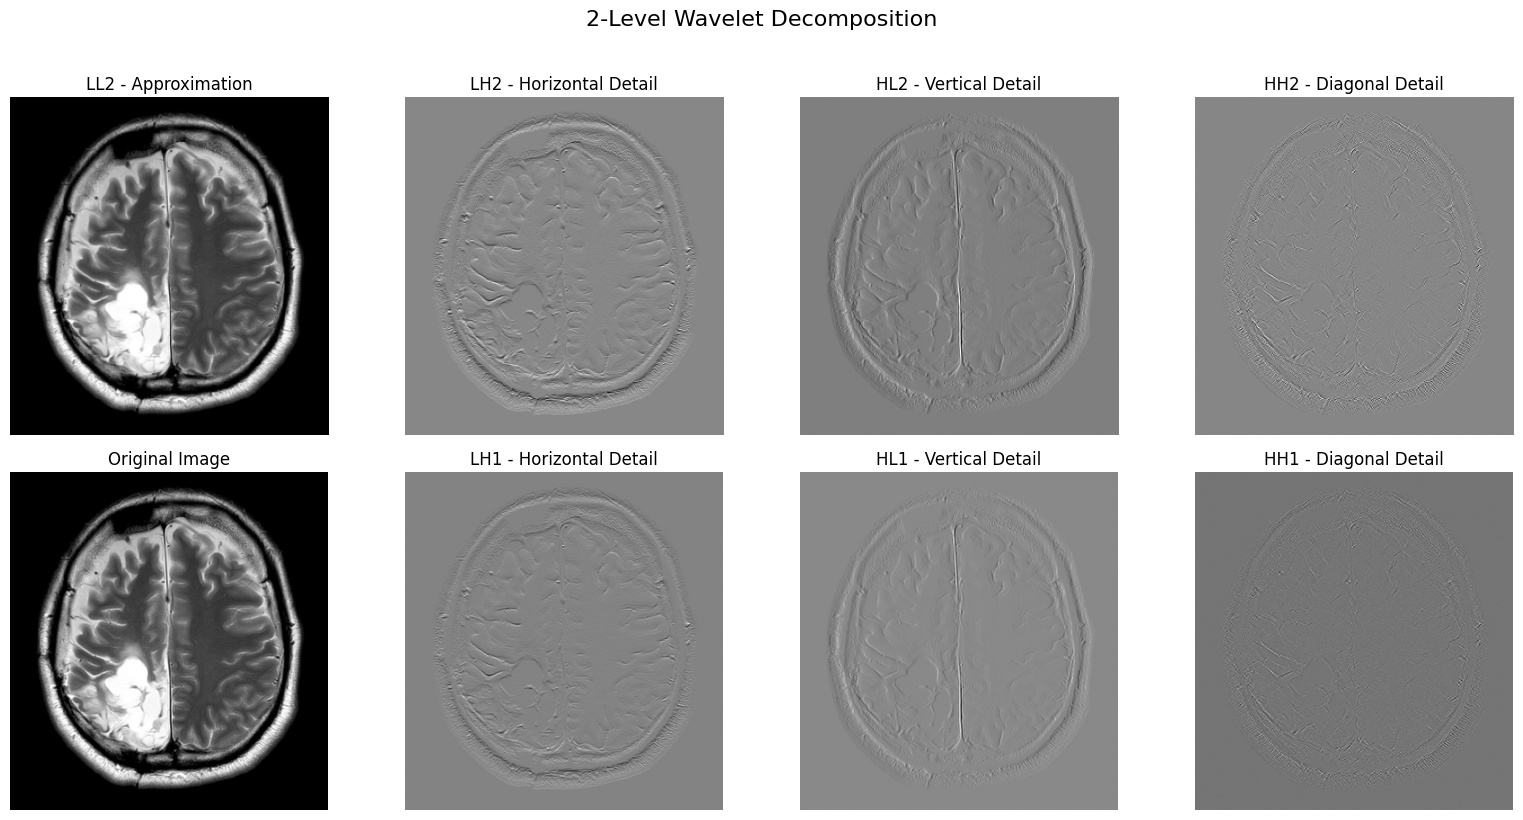

In [6]:
# Display 2-level decomposition
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Level 2 components
axes[0, 0].imshow(LL2, cmap='gray')
axes[0, 0].set_title('LL2 - Approximation')
axes[0, 0].axis('off')

axes[0, 1].imshow(LH2, cmap='gray')
axes[0, 1].set_title('LH2 - Horizontal Detail')
axes[0, 1].axis('off')

axes[0, 2].imshow(HL2, cmap='gray')
axes[0, 2].set_title('HL2 - Vertical Detail')
axes[0, 2].axis('off')

axes[0, 3].imshow(HH2, cmap='gray')
axes[0, 3].set_title('HH2 - Diagonal Detail')
axes[0, 3].axis('off')

# Level 1 components
axes[1, 0].imshow(normalized_img, cmap='gray')
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(LH1, cmap='gray')
axes[1, 1].set_title('LH1 - Horizontal Detail')
axes[1, 1].axis('off')

axes[1, 2].imshow(HL1, cmap='gray')
axes[1, 2].set_title('HL1 - Vertical Detail')
axes[1, 2].axis('off')

axes[1, 3].imshow(HH1, cmap='gray')
axes[1, 3].set_title('HH1 - Diagonal Detail')
axes[1, 3].axis('off')

plt.suptitle('2-Level Wavelet Decomposition', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Display 3-Level Decomposition Components

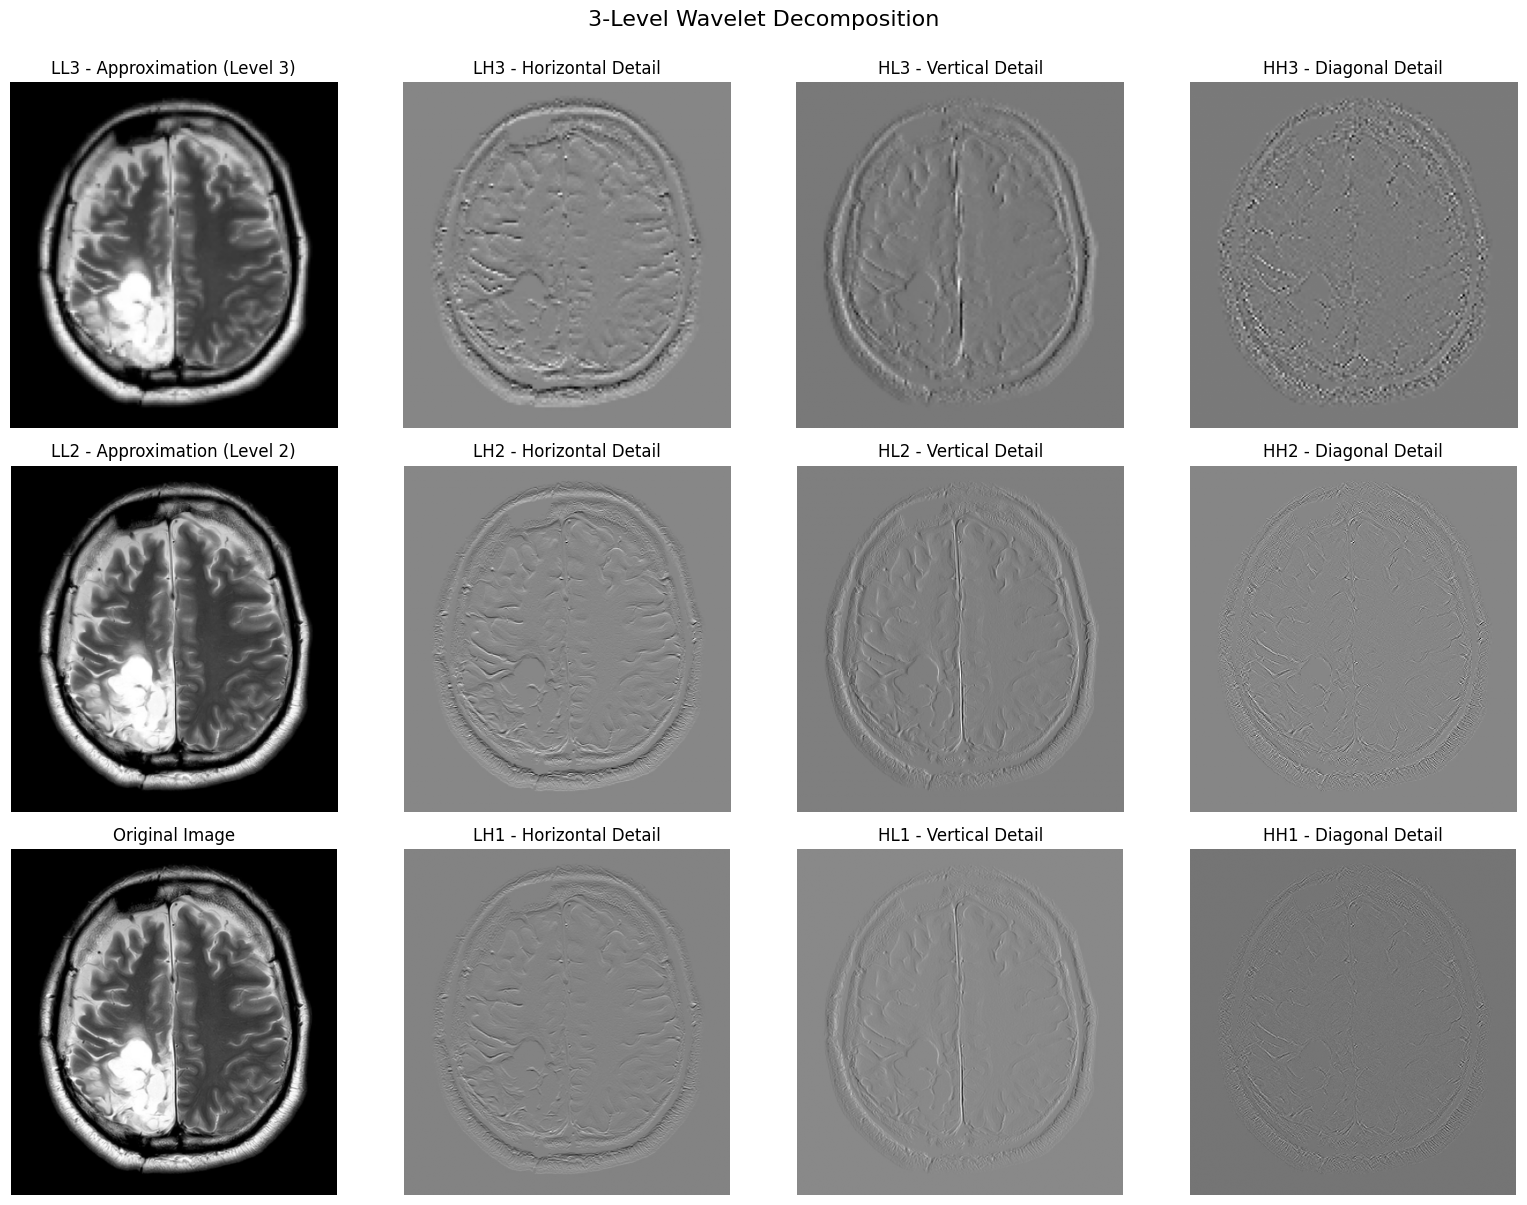

In [7]:
# Display 3-level decomposition
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Level 3 components
axes[0, 0].imshow(LL3, cmap='gray')
axes[0, 0].set_title('LL3 - Approximation (Level 3)')
axes[0, 0].axis('off')

axes[0, 1].imshow(LH3, cmap='gray')
axes[0, 1].set_title('LH3 - Horizontal Detail')
axes[0, 1].axis('off')

axes[0, 2].imshow(HL3, cmap='gray')
axes[0, 2].set_title('HL3 - Vertical Detail')
axes[0, 2].axis('off')

axes[0, 3].imshow(HH3, cmap='gray')
axes[0, 3].set_title('HH3 - Diagonal Detail')
axes[0, 3].axis('off')

# Level 2 components
axes[1, 0].imshow(LL2, cmap='gray')
axes[1, 0].set_title('LL2 - Approximation (Level 2)')
axes[1, 0].axis('off')

axes[1, 1].imshow(LH2_3, cmap='gray')
axes[1, 1].set_title('LH2 - Horizontal Detail')
axes[1, 1].axis('off')

axes[1, 2].imshow(HL2_3, cmap='gray')
axes[1, 2].set_title('HL2 - Vertical Detail')
axes[1, 2].axis('off')

axes[1, 3].imshow(HH2_3, cmap='gray')
axes[1, 3].set_title('HH2 - Diagonal Detail')
axes[1, 3].axis('off')

# Level 1 components
axes[2, 0].imshow(normalized_img, cmap='gray')
axes[2, 0].set_title('Original Image')
axes[2, 0].axis('off')

axes[2, 1].imshow(LH1_3, cmap='gray')
axes[2, 1].set_title('LH1 - Horizontal Detail')
axes[2, 1].axis('off')

axes[2, 2].imshow(HL1_3, cmap='gray')
axes[2, 2].set_title('HL1 - Vertical Detail')
axes[2, 2].axis('off')

axes[2, 3].imshow(HH1_3, cmap='gray')
axes[2, 3].set_title('HH1 - Diagonal Detail')
axes[2, 3].axis('off')

plt.suptitle('3-Level Wavelet Decomposition', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## 9. Advantages of Multi-Level Decomposition

Multi-level wavelet decomposition offers several advantages:

### **1. Multi-Resolution Analysis**
- Analyze images at different scales simultaneously
- Capture both coarse and fine details at various resolutions
- Useful for detecting features of different sizes

### **2. Better Frequency Separation**
- Further separates low and high-frequency components
- Provides more detailed frequency analysis
- Enables targeted processing of specific frequency bands

### **3. Improved Compression**
- Higher compression ratios possible
- More efficient representation of image information
- JPEG2000 uses multi-level wavelet decomposition

### **4. Enhanced Feature Extraction**
- Better for extracting features at different scales
- Useful in pattern recognition and image classification
- Captures hierarchical structure of images

### **5. Noise Reduction**
- Better separation of signal from noise
- Noise typically appears in high-frequency bands
- Can be selectively removed without affecting important details

### **6. Image Processing Flexibility**
- Apply different operations at different scales
- Perform scale-dependent image enhancement
- Better control over image processing operations

## 10. Information Content Change at Deeper Levels

### **As decomposition level increases:**

### **Approximation Band (LL):**
- **Size decreases**: Each level reduces dimensions by half
  - Level 1: Original size / 2
  - Level 2: Original size / 4
  - Level 3: Original size / 8

- **Resolution decreases**: Image becomes more blurred and abstract
- **Energy concentration**: Still contains most of the image energy
- **Information compression**: More compact representation of essential information

### **Detail Bands (LH, HL, HH):**
- **Feature scale**: Capture increasingly coarser features
  - Level 1: Fine details (small edges, textures)
  - Level 2: Medium-scale features
  - Level 3: Large-scale features

- **Frequency content**: Each level captures different frequency ranges
  - Higher levels → Lower frequency details
  - Lower levels → Higher frequency details

- **Sparse representation**: Most coefficients become very small or zero
- **Noise separation**: High-frequency noise concentrated in Level 1

### **Overall Trend:**
```
Original Image → Level 1 → Level 2 → Level 3
   (Detailed)   (Less detail)  (Even less)  (Very abstract)
```

- **Progressive abstraction**: Image structure becomes simpler
- **Computational efficiency**: Fewer coefficients to process at deeper levels
- **Hierarchical representation**: From fine to coarse features

## 11. Inverse Wavelet Transform - Image Reconstruction

In [8]:
# Reconstruct image from 1-level decomposition
reconstructed_1level = pywt.idwt2((LL, (LH, HL, HH)), 'haar')

# Reconstruct image from 2-level decomposition
reconstructed_2level = pywt.waverec2(coeffs_2level, 'haar')

# Reconstruct image from 3-level decomposition
reconstructed_3level = pywt.waverec2(coeffs_3level, 'haar')

print("Image reconstruction completed!")
print(f"Original image shape: {normalized_img.shape}")
print(f"Reconstructed from 1-level: {reconstructed_1level.shape}")
print(f"Reconstructed from 2-level: {reconstructed_2level.shape}")
print(f"Reconstructed from 3-level: {reconstructed_3level.shape}")

Image reconstruction completed!
Original image shape: (1200, 1130)
Reconstructed from 1-level: (1200, 1130)
Reconstructed from 2-level: (1200, 1130)
Reconstructed from 3-level: (1200, 1130)


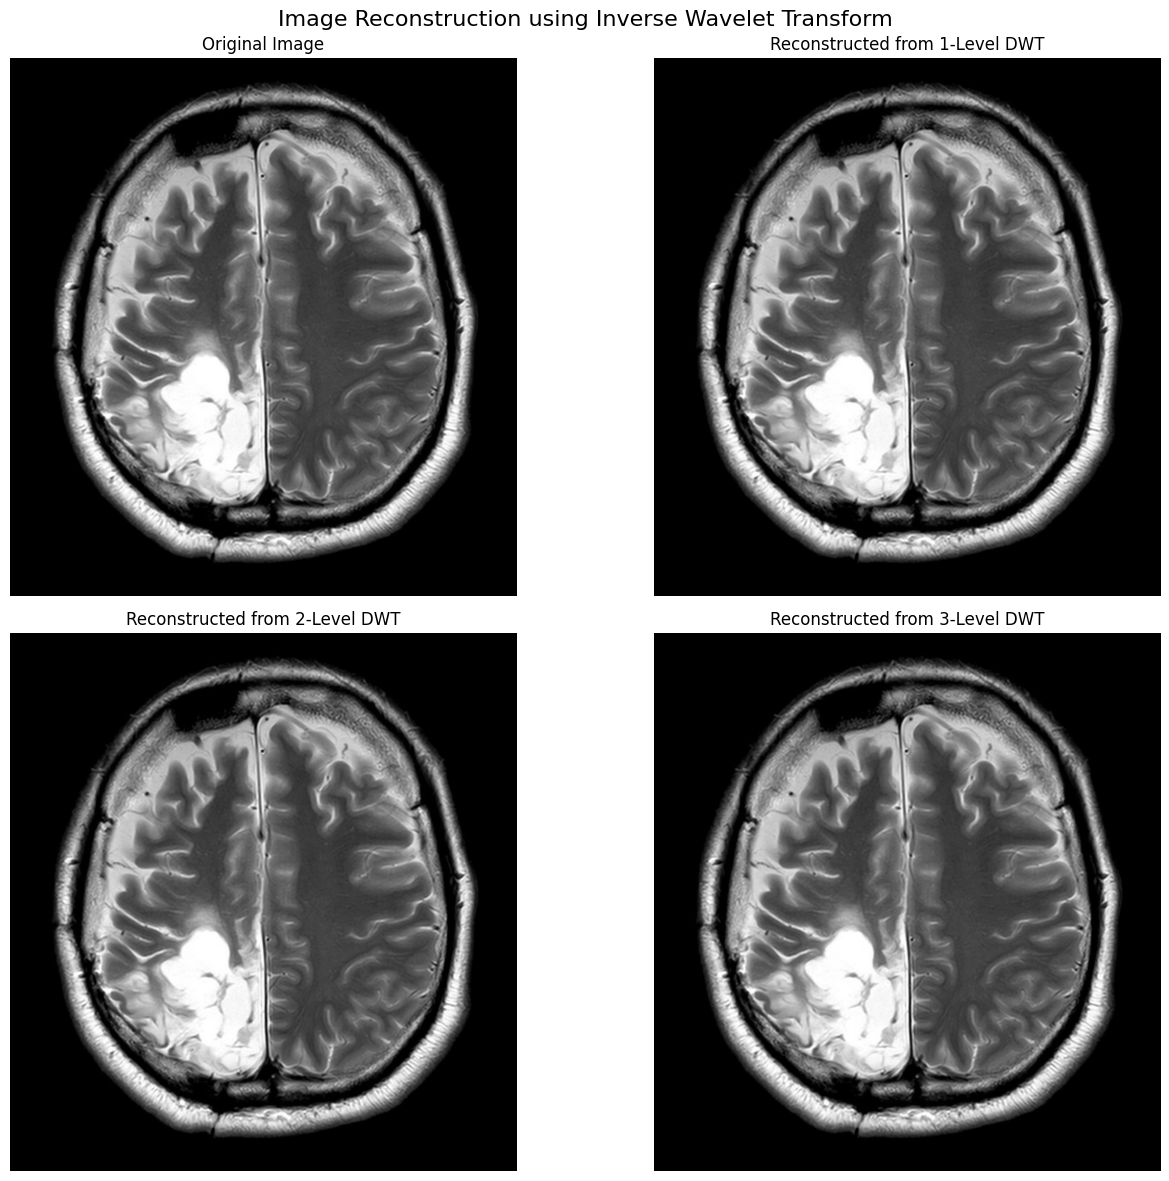

In [9]:
# Display original vs reconstructed images
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(normalized_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(reconstructed_1level, cmap='gray')
axes[0, 1].set_title('Reconstructed from 1-Level DWT')
axes[0, 1].axis('off')

axes[1, 0].imshow(reconstructed_2level, cmap='gray')
axes[1, 0].set_title('Reconstructed from 2-Level DWT')
axes[1, 0].axis('off')

axes[1, 1].imshow(reconstructed_3level, cmap='gray')
axes[1, 1].set_title('Reconstructed from 3-Level DWT')
axes[1, 1].axis('off')

plt.suptitle('Image Reconstruction using Inverse Wavelet Transform', fontsize=16)
plt.tight_layout()
plt.show()